### t-test Hypothesis Testinng

Whenever we are comparing sample mean with Population mean we are performing t-test
Types of t-test : 
1. 1- sample t-test (from scipy.stats import ttest_1samp)
2. 2- sample t-test (from scipy.stats import ttest_2samp)

Formula : 
1. t = (x - mu)/(s/square-root of n)
    1. x - sample mean
    2. mu - population mean
    3. s - sample standard deviation
    4. n - sample size

In [3]:
from scipy.stats import ttest_1samp
import numpy as np

In [2]:
sample_salary = [52000,51000,49500,53000,48000,50000,50500,51500,49800,49000] # sample salaries in company
avg_salary= 50000 # this is mean of population - avg salary of employees in company

Now a we have 1 sample and population mean salary apply t-test formula to calculate 

In [3]:
ttest_1samp(sample_salary, avg_salary)

TtestResult(statistic=np.float64(0.9135161792978956), pvalue=np.float64(0.3847901317073621), df=np.int64(9))

In response we get 
1. statistic=np.float64(0.9135161792978956), 
2. pvalue=np.float64(0.3847901317073621), 
3. df=np.int64(9)

Based on this we are failed to reject the Null Hypothesis - mean default Null Hypothesis is correct

### Internal calculation
1. Population mean(mu)= 50k (Null Hypothesis)
2. sample mean(x) = 50430
3. standard deviation of sample mean (s)= how spread out the salaries from mean = 1552.6
4. standard error (SE) = average woggle room = s/underscore of n = 1552.6/underscore of 10 = 490.2
5. statistics (t) = how far our sample mean is from our claimed mean(50k) in terms of Standard error
    1. t= (sample_mean - population_mean)/ standard_error
    2. t= (50430 - 50000)/ 490.2 = 430/490.2 = 0.913
6. Degrees of freedom = n-1 = 10-1 = 9
7. Significance level (alpha)= 0.05
8. p-value = Probability of seeing difference this large (larger) if the null hypothesis were true
    1. for t= 0.9138 and df= 9, alpha=0.05
    2. p=value= 0.3848
    3. Meaning - if true avr salary is really 50k, you will see a diference like this (430) 38% of the time just by chance.



### PLoting graph need to calculate SE, t by formulas

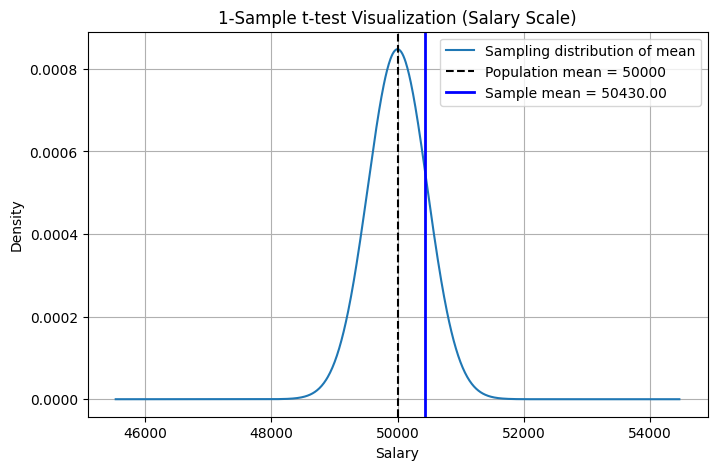

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Sample data
sample_salary = [52000,51000,49500,53000,48000,50000,50500,51500,49800,49000]
avg_salary = 50000  # Population mean

# Calculate sample statistics
n = len(sample_salary)
sample_mean = np.mean(sample_salary)
sample_std = np.std(sample_salary, ddof=1)
se = sample_std / np.sqrt(n)

# t-test statistic
t_stat = (sample_mean - avg_salary) / se
df = n - 1
p_value = stats.t.sf(np.abs(t_stat), df) * 2

# Salary scale (x-axis around population mean)
x = np.linspace(avg_salary - 3*sample_std, avg_salary + 3*sample_std, 1000)
y = stats.norm.pdf(x, avg_salary, se)  # Normal approx for visualization

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Sampling distribution of mean")

# Mark population mean
plt.axvline(avg_salary, color="black", linestyle="--", label=f"Population mean = {avg_salary}")

# Mark sample mean
plt.axvline(sample_mean, color="blue", linestyle="-", linewidth=2, label=f"Sample mean = {sample_mean:.2f}")

plt.title("1-Sample t-test Visualization (Salary Scale)")
plt.xlabel("Salary")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


### 2-sample Hypothesis Testing

In [12]:
import scipy.stats as stats


In [13]:
class_a = [85,90,88,75,95]

class_b = [80,70,78,85,82]
stats.ttest_ind(class_a, class_b)

TtestResult(statistic=np.float64(1.818827335164935), pvalue=np.float64(0.10644300564634536), df=np.float64(8.0))

Que1 . Avg gym weight of dumbells is 100lbs. Trainer belief avg weight is more. A random sample of 5 dubmels with avg of 110lbs ans standard deviation 0f 18lbs. Using Hypothesis testing check whether the trainer claim can be supported with 95% confidence level.

### Steps to be follows for each problems:
1. setup Null and Alternate Hypothesis. Identify whether it is one-side(right/left) or 2-side hypothesis.
2. Choose significance level(alpha) and find critical value
3. Find the test statistics, find p-value
4. Compare p-value and alpha-value

In [9]:
# H0 = Null Hypothesis= Dumbell Avg weight is 100lbs
# H1 = Alternate Hypothesis - Dumbell Avg weight is more than 100lbs (right tell)
pop_mean=90
sample_mean=110
sample_size= 5
sample_std_dev= 18
alpha = 0.05
df= sample_size - 1

# first calculate t-statisticd
t_stat= (sample_mean - pop_mean)/ (sample_std_dev / np.sqrt(sample_size))
t_stat # 2.4845

np.float64(2.4845199749997664)

In [ ]:
# second - calculate critical value
t_critical= stats.t.ppf(1- alpha, df)
t_critical #2.131846

np.float64(2.131846786326649)

1. Here we are calculating right tail prob that why we are substracting it from 1 and here we are going to calculate prob that lies more than 90 lbs 
2. so we are computing cumulative density function.

In [ ]:
# third - calculate p-value
p_value= 1 - stats.t.cdf(t_stat,df)
p_value #0.0339

np.float64(0.03394078010477908)

In [16]:
# Here p_value < alpha - it mean we reject Null Hypothesis - Their is an evidence to support that average weight is greater than 90 pounds.